In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
import os

data_dir = "/kaggle/input/datasets/msambare/fer2013"

# Count images per class per split
for split in ["train", "test"]:
    print(f"\n{split.upper()}")
    for emotion in os.listdir(f"{data_dir}/{split}"):
        count = len(os.listdir(f"{data_dir}/{split}/{emotion}"))
        print(f"  {emotion}: {count} images")


TRAIN
  surprise: 3171 images
  fear: 4097 images
  angry: 3995 images
  neutral: 4965 images
  sad: 4830 images
  disgust: 436 images
  happy: 7215 images

TEST
  surprise: 831 images
  fear: 1024 images
  angry: 958 images
  neutral: 1233 images
  sad: 1247 images
  disgust: 111 images
  happy: 1774 images


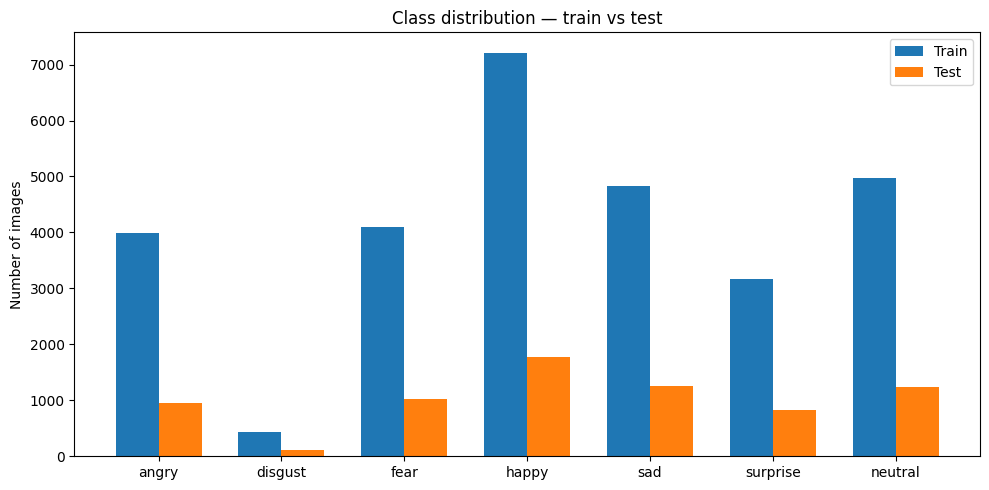

In [12]:
emotions = ["angry", "disgust", "fear", "happy", "sad", "surprise", "neutral"]
train_counts = [3995, 436, 4097, 7215, 4830, 3171, 4965]
test_counts = [958, 111, 1024, 1774, 1247, 831, 1233]

x = np.arange(len(emotions))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, train_counts, width, label="Train")
ax.bar(x + width/2, test_counts, width, label="Test")
ax.set_xticks(x)
ax.set_xticklabels(emotions)
ax.set_title("Class distribution — train vs test")
ax.set_ylabel("Number of images")
ax.legend()
plt.tight_layout()
plt.show()

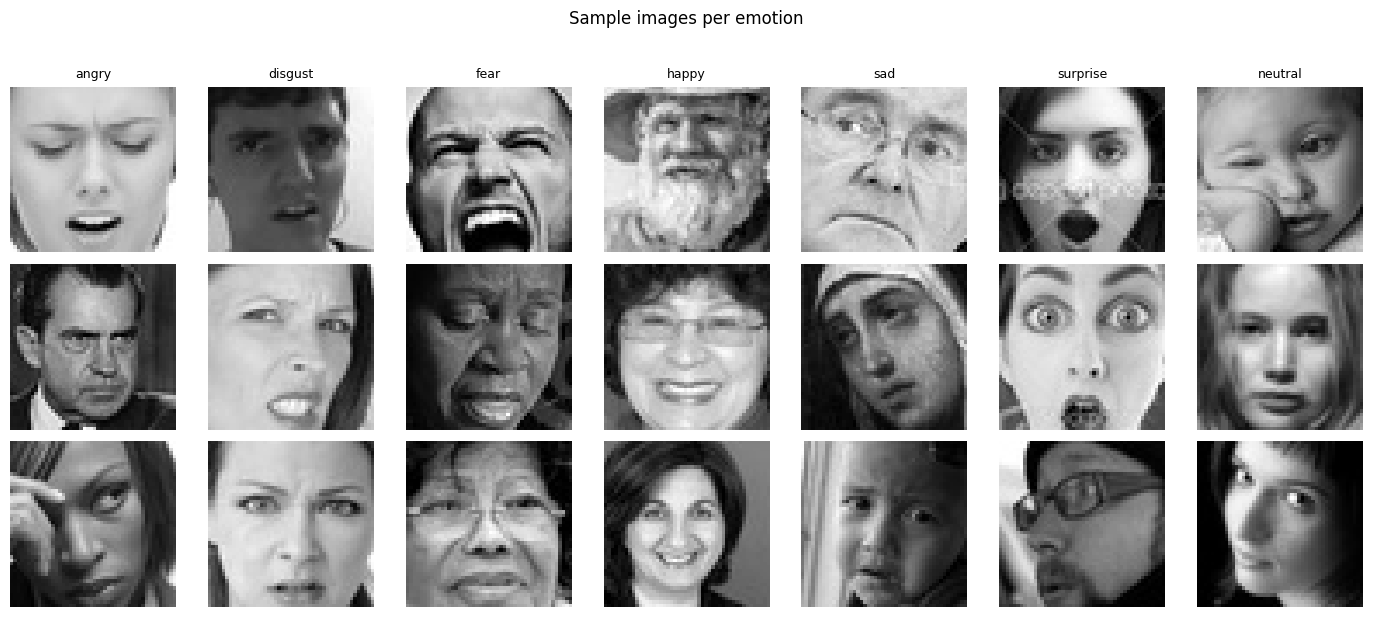

In [13]:
from PIL import Image

fig, axes = plt.subplots(3, 7, figsize=(14, 6))

for col, emotion in enumerate(emotions):
    folder = f"{data_dir}/train/{emotion}"
    images = os.listdir(folder)[:3]
    for row, img_file in enumerate(images):
        img = Image.open(f"{folder}/{img_file}")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(emotion, fontsize=9)

plt.suptitle("Sample images per emotion", y=1.02)
plt.tight_layout()
plt.show()

In [14]:
import numpy as np
from PIL import Image

pixel_values = []

for emotion in emotions:
    folder = f"{data_dir}/train/{emotion}"
    for img_file in os.listdir(folder):
        img = Image.open(f"{folder}/{img_file}").convert("L")
        img = img.resize((48, 48))
        pixel_values.append(np.array(img))

pixel_values = np.array(pixel_values) / 255.0
print(f"Mean: {pixel_values.mean():.4f}")
print(f"Std:  {pixel_values.std():.4f}")

Mean: 0.5077
Std:  0.2551
